# Notebook 02 — Exploratory Data Analysis (EDA)

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries loaded')

Libraries loaded


## Step 1: Load the labelled dataset

In [21]:
df = pd.read_csv('../data/raw/reviews_labelled.csv')
print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Dataset shape: (2209, 8)
Columns: ['review_id', 'review_text', 'star_rating', 'date', 'app_id', 'app_category', 'category_label', 'category_name']


,review_id,review_text,star_rating,date,app_id,app_category,category_label,category_name
0,570b5412-5b91-48bb-8c06-963879515606,Android (Oxygen OS 16): home screen widget is ...,1,2026-06-16 18:22:10,com.todoist,productivity,0,Bug Report
1,515ec419-cce5-41da-aaff-5779f2031805,EDIT: I reached out to support as advised in t...,2,2026-06-16 16:36:06,com.todoist,productivity,1,Feature Request
2,75f42825-a30b-4237-9afe-c051a23b6e63,"not working on oneplus 9rt , can't login",1,2026-06-16 16:35:08,com.todoist,productivity,0,Bug Report
3,aa395a6b-07b5-422e-960e-e1317436b2ac,Yesterday I mentioned that a task disappeared ...,1,2026-06-16 03:31:49,com.todoist,productivity,0,Bug Report
4,41f403b4-c9a4-4bc3-bc29-756df20edac7,"Installed it, created an account, realized I n...",1,2026-06-15 19:18:12,com.todoist,productivity,2,UX Feedback


## Step 2: Dataset overview

In [24]:
print('=== DATASET OVERVIEW ===')
print(f'Total reviews:     {len(df)}')
print(f'Unique apps:       {df["app_id"].nunique()}')
print(f'App categories:    {df["app_category"].nunique()}')
print(f'\nMissing values:')
print(df.isnull().sum())
print(f'\nStar rating distribution:')
print(df['star_rating'].value_counts().sort_index())

=== DATASET OVERVIEW ===
Total reviews:     2209
Unique apps:       11
App categories:    5

Missing values:
review_id         0
review_text       0
star_rating       0
date              0
app_id            0
app_category      0
category_label    0
category_name     0
review_length     0
dtype: int64

Star rating distribution:
star_rating
1    860
2    190
3    166
4    156
5    837
Name: count, dtype: int64


## Step 3: Review length distribution

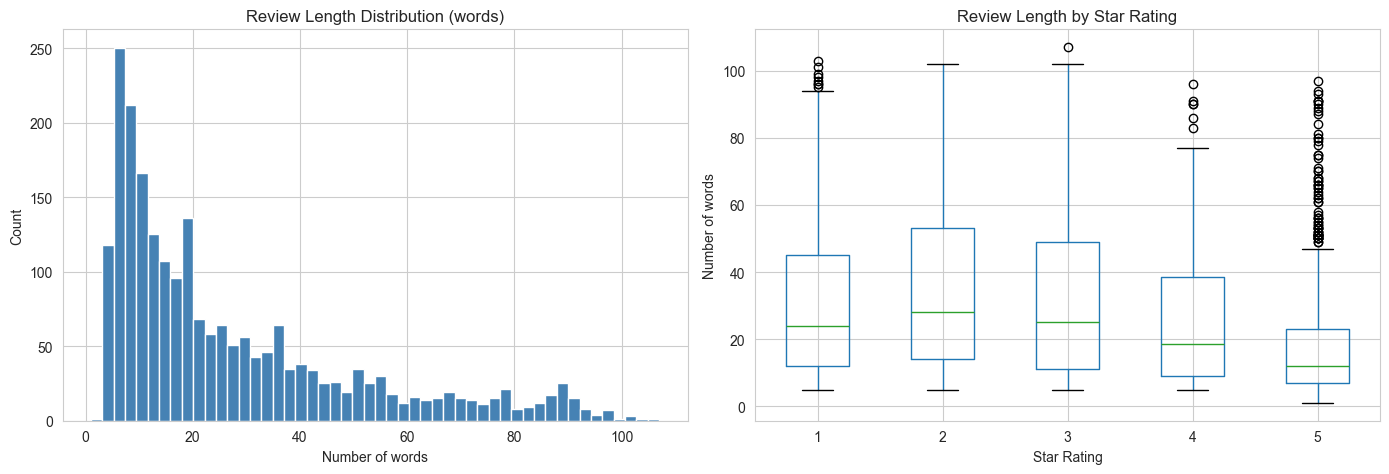

Average review length: 26.9 words
Median review length:  18.0 words
Max review length:     107 words

Reviews exceeding 128 words (approx. BERT truncation point): 0 (0.0%)


In [26]:
df['review_length'] = df['review_text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['review_length'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Review Length Distribution (words)')
axes[0].set_xlabel('Number of words')
axes[0].set_ylabel('Count')

df.boxplot(column='review_length', by='star_rating', ax=axes[1])
axes[1].set_title('Review Length by Star Rating')
axes[1].set_xlabel('Star Rating')
axes[1].set_ylabel('Number of words')
plt.suptitle('')

plt.tight_layout()
plt.savefig('../reports/review_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Average review length: {df["review_length"].mean():.1f} words')
print(f'Median review length:  {df["review_length"].median():.1f} words')
print(f'Max review length:     {df["review_length"].max()} words')
print(f'\nReviews exceeding 128 words (approx. BERT truncation point): '
      f'{(df["review_length"] > 128).sum()} ({(df["review_length"] > 128).mean()*100:.1f}%)')

## Step 4: Star rating distribution

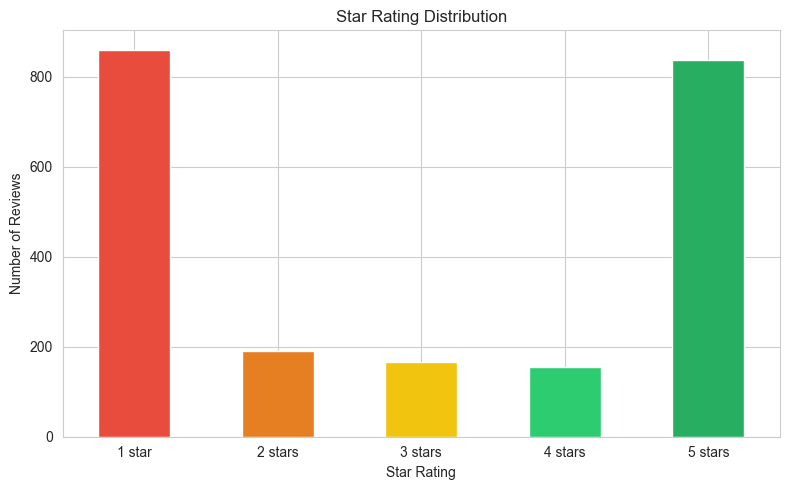

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
df['star_rating'].value_counts().sort_index().plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title('Star Rating Distribution')
ax.set_xlabel('Star Rating')
ax.set_ylabel('Number of Reviews')
ax.set_xticklabels(['1 star', '2 stars', '3 stars', '4 stars', '5 stars'], rotation=0)
plt.tight_layout()
plt.savefig('../reports/star_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5: Reviews per app category

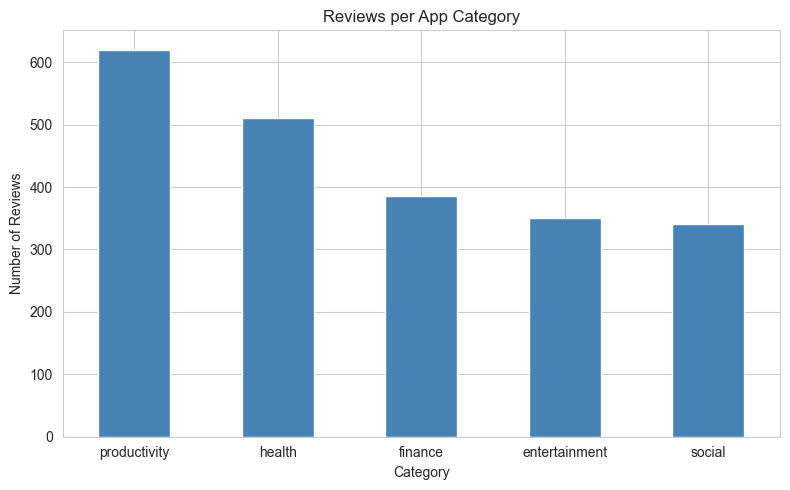

In [28]:
fig, ax = plt.subplots(figsize=(8, 5))
df['app_category'].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Reviews per App Category')
ax.set_xlabel('Category')
ax.set_ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/reviews_per_category.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6: Vocabulary overview 

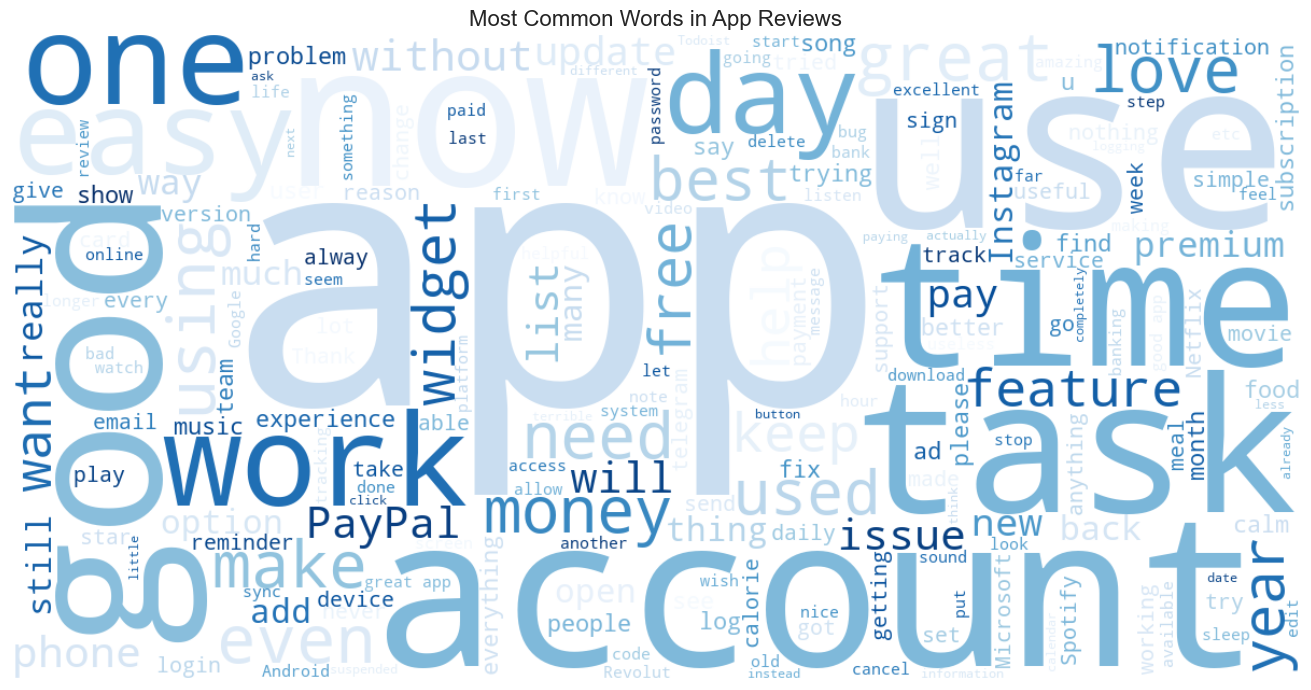

In [29]:
all_text = ' '.join(df['review_text'].tolist())

wc = WordCloud(
    width=1200, height=600,
    background_color='white',
    max_words=200,
    colormap='Blues'
).generate(all_text)

plt.figure(figsize=(14, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in App Reviews', fontsize=16)
plt.tight_layout()
plt.savefig('../reports/wordcloud_all.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 7: Qualitative spot-check

In [30]:
for rating in [1, 2, 3, 4, 5]:
    sample = df[df['star_rating'] == rating]['review_text'].sample(2, random_state=42).tolist()
    print(f'\n=== {rating} Star Reviews ===')
    for i, text in enumerate(sample, 1):
        print(f'{i}. {text[:200]}...' if len(text) > 200 else f'{i}. {text}')


=== 1 Star Reviews ===
1. can't able to login please help me
2. Instagram, why do you want us to pay you? aren't you earning enough, just like other apps? where is premium coming from? please stop it and work on equality!

=== 2 Star Reviews ===
1. trying to confirm my password from my phone email app but every time I switch out of the PayPal app, it errors and wants me to send another code. so messed up. I need the money in there to combine wit...
2. pls make it available in all country like Ethiopia pls

=== 3 Star Reviews ===
1. works good, new pricing is ridiculous.
2. I was unable to manage my subscription by reversing my request to cancel

=== 4 Star Reviews ===
1. Just started with new update. A great improvement on the last design.
2. my go to for Asian dramas

=== 5 Star Reviews ===
1. Perfect ! easy to work with !
2. The app is great. Best banking services I know. That would be great. + proper monthly account statement pls (PDF) with all transaction details (like an official

## Step 8: Class imbalance — star rating

=== CLASS IMBALANCE ANALYSIS — STAR RATING ===

Star Rating Distribution:
1 stars:  860 reviews (38.93%)
2 stars:  190 reviews ( 8.60%)
3 stars:  166 reviews ( 7.51%)
4 stars:  156 reviews ( 7.06%)
5 stars:  837 reviews (37.89%)


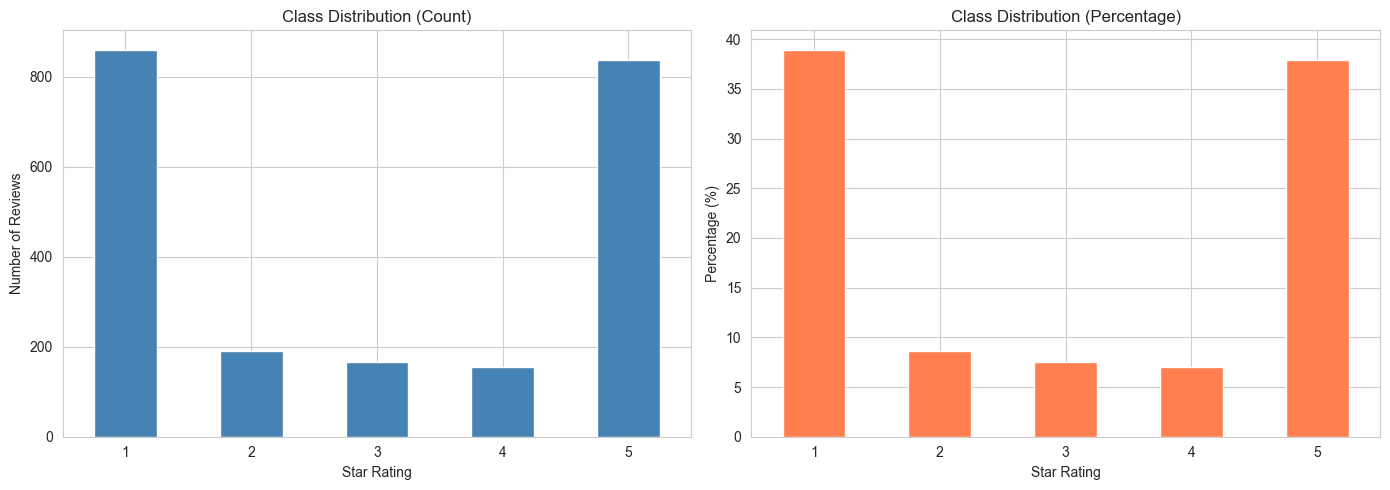


Imbalance Ratio (Majority/Minority): 5.51x


In [31]:
print('=== CLASS IMBALANCE ANALYSIS — STAR RATING ===\n')

rating_counts = df['star_rating'].value_counts().sort_index()
rating_percentages = df['star_rating'].value_counts(normalize=True).sort_index() * 100

print('Star Rating Distribution:')
for rating in sorted(df['star_rating'].unique()):
    count = rating_counts[rating]
    pct = rating_percentages[rating]
    print(f'{rating} stars: {count:4d} reviews ({pct:5.2f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rating_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Class Distribution (Count)')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Number of Reviews')
axes[0].set_xticklabels([f'{int(x)}' for x in rating_counts.index], rotation=0)

rating_percentages.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Class Distribution (Percentage)')
axes[1].set_xlabel('Star Rating')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xticklabels([f'{int(x)}' for x in rating_percentages.index], rotation=0)

plt.tight_layout()
plt.savefig('../reports/class_imbalance_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

majority_class = rating_counts.max()
minority_class = rating_counts.min()
imbalance_ratio = majority_class / minority_class
print(f'\nImbalance Ratio (Majority/Minority): {imbalance_ratio:.2f}x')

## Step 9: App category × star rating

=== CATEGORY x RATING CROSS-TABULATION ===

star_rating      1    2    3    4    5   All
app_category                                
entertainment  150   23   20   23  135   351
finance        141   24   11   21  189   386
health         205   65   59   28  154   511
productivity   171   61   58   69  261   620
social         193   17   18   15   98   341
All            860  190  166  156  837  2209


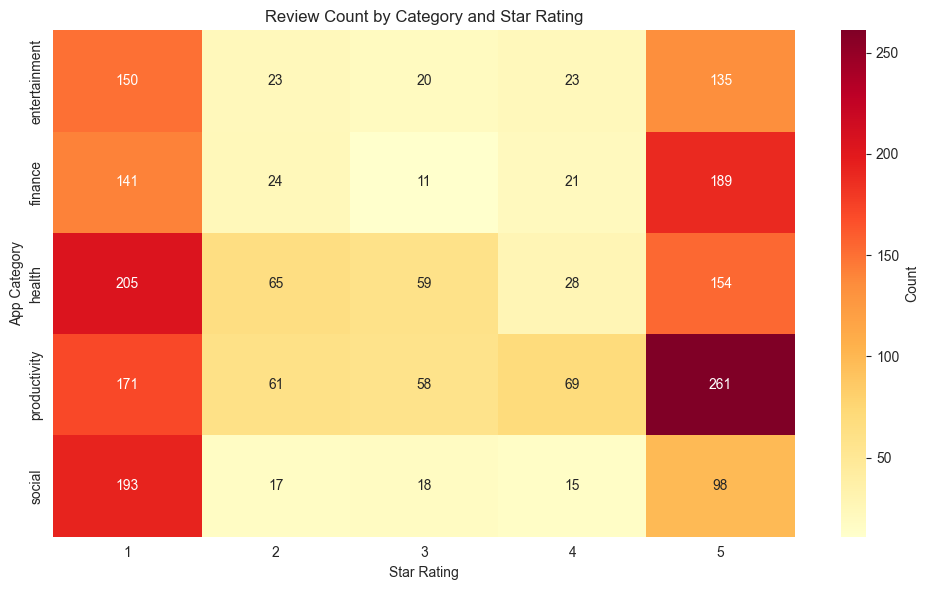


Average Rating by Category:
                mean  count    std
app_category                      
entertainment  2.915    351  1.839
finance        3.241    386  1.867
health         2.728    511  1.710
productivity   3.303    620  1.706
social         2.437    341  1.789


In [32]:
print('=== CATEGORY x RATING CROSS-TABULATION ===\n')

crosstab = pd.crosstab(df['app_category'], df['star_rating'], margins=True)
print(crosstab)

fig, ax = plt.subplots(figsize=(10, 6))
crosstab_no_margins = pd.crosstab(df['app_category'], df['star_rating'])
sns.heatmap(crosstab_no_margins, annot=True, fmt='d', cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Count'})
ax.set_title('Review Count by Category and Star Rating')
ax.set_xlabel('Star Rating')
ax.set_ylabel('App Category')
plt.tight_layout()
plt.savefig('../reports/category_rating_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

avg_rating_by_category = df.groupby('app_category')['star_rating'].agg(['mean', 'count', 'std']).round(3)
print('\nAverage Rating by Category:')
print(avg_rating_by_category)

## Step 10: Data quality checks

=== DATA QUALITY ANALYSIS ===

Duplicate review texts: 0
Duplicate review + rating combinations: 0

Empty reviews: 0
Reviews with < 3 words: 1
Reviews with URLs: 0
Reviews with emojis: 155

Text Quality Statistics:
Avg words per review: 26.91
Median words per review: 18.00
Std deviation: 23.19

Reviews by Length Category:
length_category
Very Short (1-5)    119
Short (6-10)        552
Medium (11-20)      540
Long (21-50)        646
Very Long (50+)     352
Name: count, dtype: int64


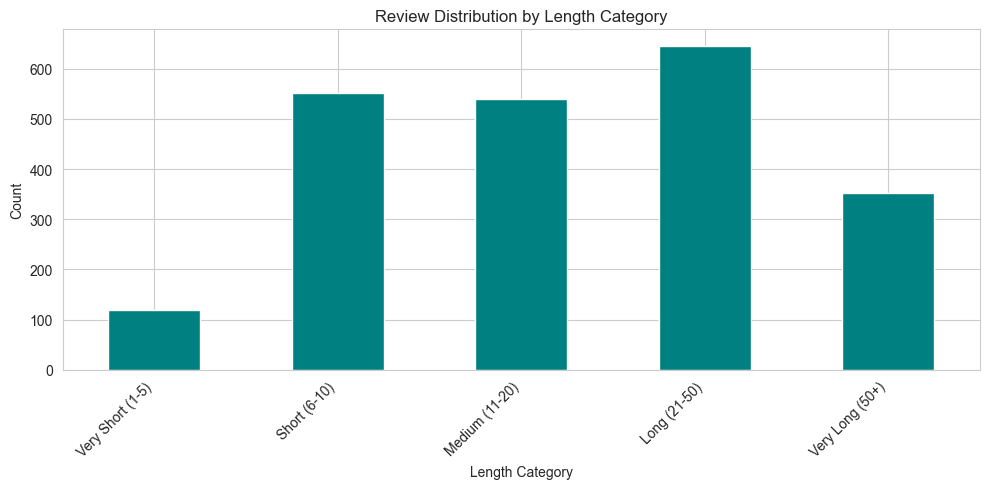

In [33]:
print('=== DATA QUALITY ANALYSIS ===\n')

duplicate_reviews = df['review_text'].duplicated().sum()
duplicate_rows = df.duplicated(subset=['review_text', 'star_rating']).sum()
print(f'Duplicate review texts: {duplicate_reviews}')
print(f'Duplicate review + rating combinations: {duplicate_rows}')

empty_reviews = (df['review_text'].str.len() == 0).sum()
short_reviews = (df['review_text'].str.split().str.len() < 3).sum()
print(f'\nEmpty reviews: {empty_reviews}')
print(f'Reviews with < 3 words: {short_reviews}')

has_url = df['review_text'].astype('object').str.contains(r'http|www', regex=True, case=False, na=False).sum()
has_emojis = df['review_text'].astype('object').str.contains(r'[\U0001F300-\U0001F9FF]', regex=True, na=False).sum()
print(f'Reviews with URLs: {has_url}')
print(f'Reviews with emojis: {has_emojis}')

print(f'\nText Quality Statistics:')
print(f'Avg words per review: {df["review_length"].mean():.2f}')
print(f'Median words per review: {df["review_length"].median():.2f}')
print(f'Std deviation: {df["review_length"].std():.2f}')

df['length_category'] = pd.cut(
    df['review_length'],
    bins=[0, 5, 10, 20, 50, float('inf')],
    labels=['Very Short (1-5)', 'Short (6-10)', 'Medium (11-20)', 'Long (21-50)', 'Very Long (50+)']
)

print('\nReviews by Length Category:')
print(df['length_category'].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(10, 5))
df['length_category'].value_counts().sort_index().plot(kind='bar', ax=ax, color='teal', edgecolor='white')
ax.set_title('Review Distribution by Length Category')
ax.set_xlabel('Length Category')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/review_length_categories.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 11: Stratification coverage check

=== STRATIFICATION VERIFICATION ===

Reviews per Category-Rating Stratum:
star_rating      1   2   3   4    5
app_category                       
entertainment  150  23  20  23  135
finance        141  24  11  21  189
health         205  65  59  28  154
productivity   171  61  58  69  261
social         193  17  18  15   98

Minimum samples in any stratum: 11
Maximum samples in any stratum: 261
Ratio (Max/Min): 23.73x

OK: All strata have at least 5 samples — adequate for the planned 70/15/15 split.


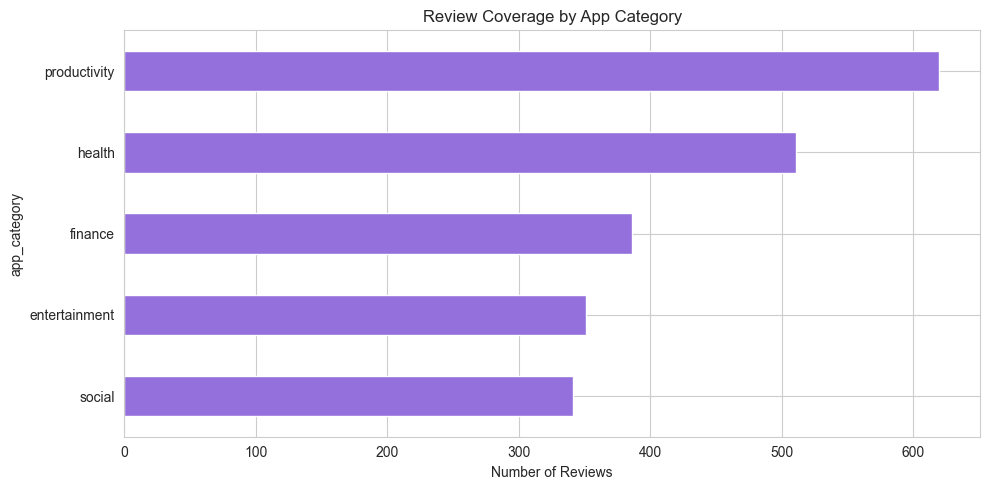

In [34]:
print('=== STRATIFICATION VERIFICATION ===\n')

strata_counts = df.groupby(['app_category', 'star_rating']).size().reset_index(name='count')
print('Reviews per Category-Rating Stratum:')
print(strata_counts.pivot(index='app_category', columns='star_rating', values='count').fillna(0).astype(int))

min_stratum = strata_counts['count'].min()
max_stratum = strata_counts['count'].max()
print(f'\nMinimum samples in any stratum: {min_stratum}')
print(f'Maximum samples in any stratum: {max_stratum}')
print(f'Ratio (Max/Min): {max_stratum/min_stratum:.2f}x')

if min_stratum < 5:
    print('\nWARNING: Some strata have fewer than 5 samples. A 70/15/15 split could leave the '
          '15% validation or test slice with zero examples of that stratum.')
else:
    print('\nOK: All strata have at least 5 samples — adequate for the planned 70/15/15 split.')

fig, ax = plt.subplots(figsize=(10, 5))
category_counts = df['app_category'].value_counts().sort_values()
category_counts.plot(kind='barh', ax=ax, color='mediumpurple', edgecolor='white')
ax.set_title('Review Coverage by App Category')
ax.set_xlabel('Number of Reviews')
plt.tight_layout()
plt.savefig('../reports/stratification_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 12: Feature exploration

=== FEATURE CORRELATION WITH STAR RATING ===

Correlation (Review Length vs Star Rating): -0.2613
Correlation (Avg Word Length vs Star Rating): -0.0071
Correlation (Has Punctuation vs Star Rating): -0.0301

Average Review Features by Star Rating:
            review_length         avg_word_length        has_punctuation  \
                     mean     std            mean    std            mean   
star_rating                                                                
1                  31.712  24.444           4.528  0.666           0.171   
2                  36.226  26.662           4.444  0.620           0.158   
3                  33.831  26.430           4.440  0.601           0.157   
4                  26.391  22.035           4.426  0.675           0.115   
5                  18.585  17.189           4.516  0.877           0.149   

            uppercase_ratio  
                       mean  
star_rating                  
1                     0.032  
2                     0.

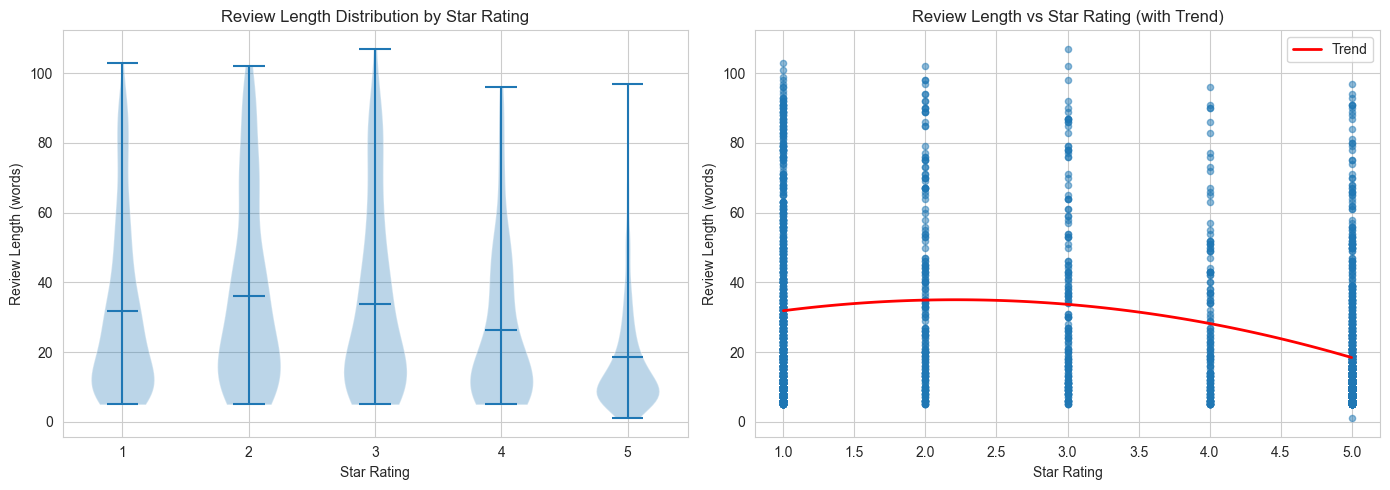

In [35]:
df['has_punctuation'] = df['review_text'].str.contains(r'[!?]', regex=True).astype(int)
df['uppercase_ratio'] = df['review_text'].apply(lambda x: sum(1 for c in x if c.isupper()) / len(x) if len(x) > 0 else 0)
df['avg_word_length'] = df['review_text'].apply(lambda x: np.mean([len(w) for w in x.split()]) if len(x.split()) > 0 else 0)

print('=== FEATURE CORRELATION WITH STAR RATING ===\n')

correlation = df['review_length'].corr(df['star_rating'])
print(f'Correlation (Review Length vs Star Rating): {correlation:.4f}')

word_len_corr = df['avg_word_length'].corr(df['star_rating'])
print(f'Correlation (Avg Word Length vs Star Rating): {word_len_corr:.4f}')

punct_corr = df['has_punctuation'].corr(df['star_rating'])
print(f'Correlation (Has Punctuation vs Star Rating): {punct_corr:.4f}')

print('\nAverage Review Features by Star Rating:')
feature_analysis = df.groupby('star_rating').agg({
    'review_length': ['mean', 'std'],
    'avg_word_length': ['mean', 'std'],
    'has_punctuation': 'mean',
    'uppercase_ratio': 'mean'
}).round(3)
print(feature_analysis)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

parts = axes[0].violinplot(
    [df[df['star_rating'] == r]['review_length'].values for r in sorted(df['star_rating'].unique())],
    positions=sorted(df['star_rating'].unique()),
    showmeans=True
)
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Review Length (words)')
axes[0].set_title('Review Length Distribution by Star Rating')
axes[0].set_xticks(sorted(df['star_rating'].unique()))

axes[1].scatter(df['star_rating'], df['review_length'], alpha=0.5, s=20)
z = np.polyfit(df['star_rating'], df['review_length'], 2)
p = np.poly1d(z)
x_trend = np.linspace(df['star_rating'].min(), df['star_rating'].max(), 100)
axes[1].plot(x_trend, p(x_trend), 'r-', linewidth=2, label='Trend')
axes[1].set_xlabel('Star Rating')
axes[1].set_ylabel('Review Length (words)')
axes[1].set_title('Review Length vs Star Rating (with Trend)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/sentiment_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 13: Target class distribution — the four-category taxonomy

=== TARGET CLASS DISTRIBUTION ===
(Maalej & Nabil taxonomy: Bug Report, Feature Request, UX Feedback, Positive Praise)

Target Class Distribution:
Bug Report          :  753 reviews (34.09%)
Feature Request     :  185 reviews ( 8.37%)
UX Feedback         :  439 reviews (19.87%)
Positive Praise     :  832 reviews (37.66%)

Target Class Imbalance Ratio (Majority/Minority): 4.50x


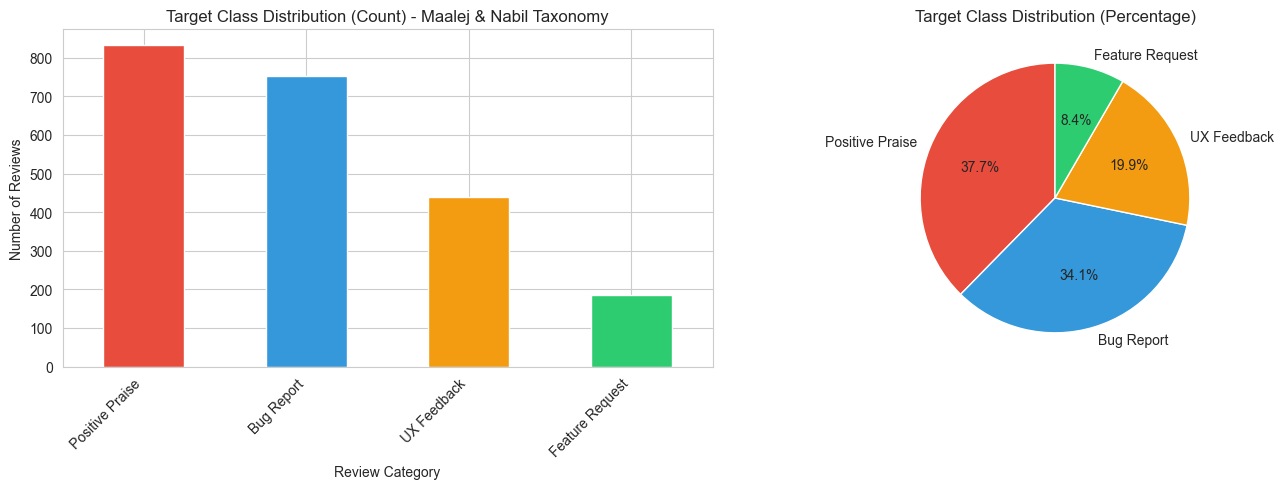



Cross-tabulation: App Category × Target Class
category_name  Bug Report  Feature Request  Positive Praise  UX Feedback   All
app_category                                                                  
entertainment         113               34              133           71   351
finance               121               20              186           59   386
health                148               45              152          166   511
productivity          225               63              263           69   620
social                146               23               98           74   341
All                   753              185              832          439  2209


In [36]:
print('=== TARGET CLASS DISTRIBUTION ===')
print('(Maalej & Nabil taxonomy: Bug Report, Feature Request, UX Feedback, Positive Praise)\n')

label_to_name = {0: 'Bug Report', 1: 'Feature Request', 2: 'UX Feedback', 3: 'Positive Praise'}

class_counts = df['category_name'].value_counts()
class_percentages = df['category_name'].value_counts(normalize=True) * 100

print('Target Class Distribution:')
for class_name in label_to_name.values():
    count = class_counts.get(class_name, 0)
    pct = class_percentages.get(class_name, 0)
    print(f'{class_name:20s}: {count:4d} reviews ({pct:5.2f}%)')

target_imbalance_ratio = class_counts.max() / class_counts.min()
print(f'\nTarget Class Imbalance Ratio (Majority/Minority): {target_imbalance_ratio:.2f}x')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#3498db', '#f39c12', '#2ecc71'], edgecolor='white')
axes[0].set_title('Target Class Distribution (Count) - Maalej & Nabil Taxonomy')
axes[0].set_xlabel('Review Category')
axes[0].set_ylabel('Number of Reviews')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

colors = ['#e74c3c', '#3498db', '#f39c12', '#2ecc71']
axes[1].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Target Class Distribution (Percentage)')

plt.tight_layout()
plt.savefig('../reports/target_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n\nCross-tabulation: App Category × Target Class')
category_label_crosstab = pd.crosstab(df['app_category'], df['category_name'], margins=True)
print(category_label_crosstab)